## Baseline models

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

In [2]:
# load database
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])
print(df.shape)
print(df.columns.tolist())

(62544, 60)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'd

### Scale down importance of earlier periods using weights

In [3]:
# Create weights assigned to each observation

df = df.sort_values("timestamp").set_index("timestamp")

def create_regime_weights(index):

    weights = pd.Series(1.0, index=index)

    # Pre-crisis
    weights.loc["2019-01-01 00:00":"2020-12-31 23:00"] = 0.6

    # Energy crisis
    weights.loc["2021-01-01 00:00":"2022-12-31 23:00"] = 0.3

    # Post-crisis
    weights.loc["2023-01-01 00:00":"2025-06-30 23:00"] = 1.0

    return weights

weights = create_regime_weights(df.index)

### Naive model (as in Biro et al)

In [4]:
# define a function that does the naive model

def predict_price_lag(df, price_col='price', day_col='day_of_week'):
    """
    Predict price using a conditional lag:
    - Tue, Wed, Thu, Fri, Sun → lag 1 (24h)
    - Sat, Mon → lag 7 (168h)
    """

    lag_1 = df[price_col].shift(24)
    lag_7 = df[price_col].shift(168)

    lag_1_days = {1, 2, 3, 4, 6}

    return pd.Series(
        np.where(df[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df.index
    )

In [5]:
# Predict with the naive model on the test data
df['price_pred_naive'] = predict_price_lag(df)

### Train-test split

In [6]:
# Fix the start of the test set
test_start = "2025-07-01"

(56592, 60)
(5952, 60)


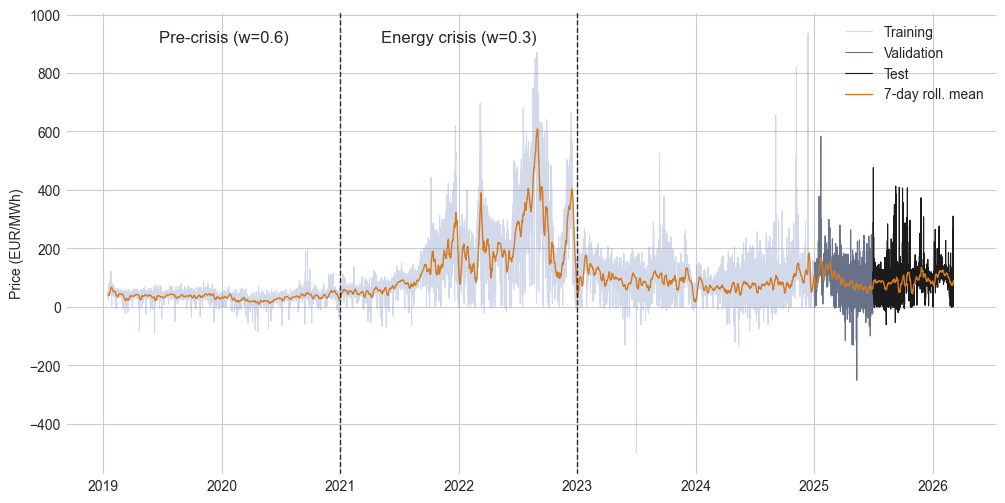

In [7]:
# Split data into train and test sample

train_df = df[df.index < test_start].copy()
test_df  = df[df.index >= test_start].copy()

validation_df = train_df[train_df.index >= "2025-01-01"]  # for now, just to show

print(train_df.shape)
print(test_df.shape)

# Plotting the train and test set
plt.figure(figsize=(12,6))

# Plot train and test
plt.plot(train_df.index, train_df['price'], color="#8DA0CB", linewidth=0.8, alpha=0.4, label='Training')
plt.plot(validation_df.index, validation_df['price'], color="#68738A", linewidth=0.8, label='Validation')
plt.plot(test_df.index, test_df['price'], color="#1B1B1B", linewidth=0.8, label='Test')

# 7-day rolling mean
plt.plot(df.index, df['price_rolling_168h'],
         color="#D37B22", linewidth=1,
         label='7-day roll. mean')

# Regime separator lines
plt.axvline(pd.Timestamp("2021-01-01 00:00"), color='black', linestyle='--', linewidth=1, alpha=0.8)
plt.axvline(pd.Timestamp("2023-01-01 00:00"), color='black', linestyle='--', linewidth=1, alpha=0.8)

# Label axes and legend
plt.xlabel("")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)

# Add text to the regimes

# --- define regime boundaries ---
split1 = pd.Timestamp("2021-01-01 00:00")
split2 = pd.Timestamp("2023-01-01 00:00")

# y-position for text (near top of plot)
y_pos = plt.ylim()[1] * 0.9

# --- region midpoints ---
x_pre   = train_df.index.min() + (split1 - train_df.index.min()) / 2
x_crisis = split1 + (split2 - split1) / 2
x_post  = split2 + (df.index.max() - split2) / 2

# --- add labels ---
plt.text(x_pre, y_pos, "Pre-crisis (w=0.6)", ha='center', fontsize=12)
plt.text(x_crisis, y_pos, "Energy crisis (w=0.3)", ha='center', fontsize=12)
#plt.text(x_post, y_pos, "Post-crisis", ha='center', fontsize=12)

# Save figure
plt.savefig("../images/price_timeseries.png", dpi=300, bbox_inches="tight")

plt.show()

### Forecast evaluation

In [8]:
# Define metrics

# Daily Average Error (DAE)
def dae(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred, index=y_true.index)

    df = pd.DataFrame({"err": np.abs(y_true - y_pred)})
    df["date"] = df.index.floor("D")

    def is_full_day(g):
        return g.index.hour.nunique() == 24

    daily = df.groupby("date").filter(is_full_day)
    return daily.groupby("date")["err"].mean().mean()

# Symmetric Mean Absolute Percentage Error (SMAPE)
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

In [9]:
# performance of naive prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_naive"])
smape_score = smape(test_df["price"], test_df["price_pred_naive"])
dae_score = dae(test_df["price"], test_df["price_pred_naive"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 23.3474
DAE: 23.3474
SMAPE: 37.6247


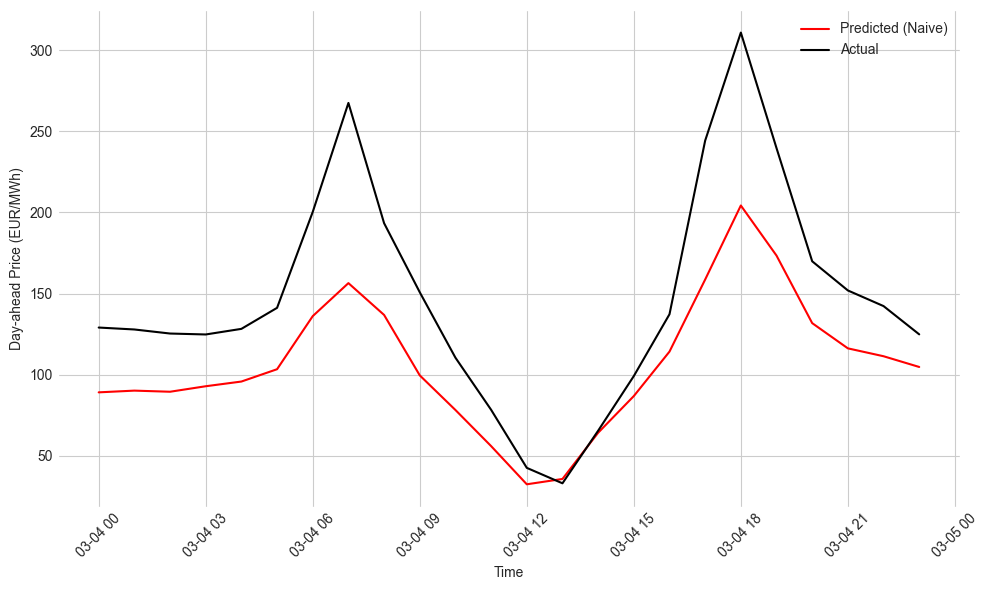

In [10]:
# Plotting true and forecasted for a specific day

day = "2026-03-04"

day_df = test_df.loc[day]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df.index, day_df['price_pred_naive'],
         color='red', label='Predicted (Naive)')

plt.plot(day_df.index, day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARX-LASSO

In [11]:
# define additional price lags (2 and 3 days ago) - similar to Biro et al
#df['price_lag_48h'] = df['price'].shift(48)
#df['price_lag_72h'] = df['price'].shift(72)

In [12]:
# function to generate all lags
def generate_hourly_lags(df, features, lags=None):
    if lags is None:
        lags = list(range(24, 73)) + list(range(168, 193))
    """
    Generate lagged features for hourly time series.

    Args:
        df: pandas DataFrame with DatetimeIndex (hourly)
        features: list of column names to generate lags for
        lags: list of integer lags in hours

    Returns:
        DataFrame with lagged features (columns named <feature>_lag_<lag>)
    """
    lagged_df = pd.DataFrame(index=df.index)

    for feature in features:
        for lag in lags:
            col_name = f"{feature}_{lag}h"
            lagged_df[col_name] = df[feature].shift(lag)

    return lagged_df

In [13]:
# list of features to be lagged
features = ["price", "total_generation", "net_export"]

# apply the lag function
lagged_features = generate_hourly_lags(df, features)

# add created lagged features to dataframe
df = pd.concat([df, lagged_features], axis=1)

/var/folders/32/6synsk4520n5033f6q7f5qd80000gn/T/ipykernel_61659/2488092906.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged_df[col_name] = df[feature].shift(lag)
/var/folders/32/6synsk4520n5033f6q7f5qd80000gn/T/ipykernel_61659/2488092906.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged_df[col_name] = df[feature].shift(lag)
/var/folders/32/6synsk4520n5033f6q7f5qd80000gn/T/ipykernel_61659/2488092906.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

In [14]:
# Fuel prices 2 days ago -- the one-day-ago price is not yet available at the time of forecasting
df['gas_price_lag_48h'] = df['gas_price'].shift(48)
df['coal_price_lag_48h'] = df['coal_price'].shift(48)
df['co2_price_lag_48h'] = df['co2_price'].shift(48)

/var/folders/32/6synsk4520n5033f6q7f5qd80000gn/T/ipykernel_61659/1148454360.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['gas_price_lag_48h'] = df['gas_price'].shift(48)
/var/folders/32/6synsk4520n5033f6q7f5qd80000gn/T/ipykernel_61659/1148454360.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['coal_price_lag_48h'] = df['coal_price'].shift(48)
/var/folders/32/6synsk4520n5033f6q7f5qd80000gn/T/ipykernel_61659/1148454360.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

In [15]:
lag_cols = [
    'price_24h', 'price_48h', 'price_72h', 'price_168h',
    'price_25h', 'price_26h', 'price_27h', 'price_28h', 'price_29h', 'price_30h',
    'price_31h', 'price_32h', 'price_33h', 'price_34h', 'price_35h', 'price_36h',
    'price_37h', 'price_38h', 'price_39h', 'price_40h', 'price_41h', 'price_42h',
    'price_43h', 'price_44h', 'price_45h', 'price_46h', 'price_47h',
    'price_49h', 'price_50h', 'price_51h', 'price_52h', 'price_53h', 'price_54h',
    'price_55h', 'price_56h', 'price_57h', 'price_58h', 'price_59h', 'price_60h',
    'price_61h', 'price_62h', 'price_63h', 'price_64h', 'price_65h', 'price_66h',
    'price_67h', 'price_68h', 'price_69h', 'price_70h', 'price_71h'
]

In [16]:
# feature set to be used in the models (modify as you like)
exog_features = [
    'load', 'wind_offshore', 'wind_onshore', 'solar',
    'load_ramp', 'renewable_ramp', 'delta_wind_forecast',
    'temperature', 'wind_speed',
    'net_export_48h', 'net_export_72h', 'net_export_168h',
    'total_generation_48h', 'total_generation_72h', 'total_generation_168h',
    'gas_price_lag_48h', 'coal_price_lag_48h', 'co2_price_lag_48h',
    'price_volatility_24h', 'is_holiday'
]

In [17]:
seasonal = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

In [18]:
# Split data with new features into train and test

train_df = df[df.index < test_start].copy()
test_df  = df[df.index >= test_start].copy()

train_df = train_df.dropna().copy()  # eliminate N/A from train (generated by lagging)

In [19]:
X_train = train_df[lag_cols + exog_features + seasonal]
y_train = train_df['price']

X_test = test_df[lag_cols + exog_features + seasonal]

In [20]:
# Standardize all features and lagged prices  (... shall we do it also on the sin and cosine time effects? )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# fit linear model with Lasso regularization

# you can experiment with different alphas
lasso = Lasso(alpha=0.5, max_iter=10000)
lasso.fit(X_train_scaled, y_train, sample_weight=weights.loc[X_train.index])

Lasso(alpha=0.5, max_iter=10000)

In [22]:
# predict on test-set
test_df['price_pred_arxlasso'] = lasso.predict(X_test_scaled)

In [23]:
# performance of ARX-LASSO prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_arxlasso"])
smape_score = smape(test_df["price"], test_df["price_pred_arxlasso"])
dae_score = dae(test_df["price"], test_df["price_pred_arxlasso"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 15.0119
DAE: 15.0119
SMAPE: 28.2090


In [24]:
# show features with non-zero coefficients
coef_series = pd.Series(lasso.coef_, index=lag_cols + exog_features + seasonal)
selected_features = coef_series[coef_series != 0].sort_values(ascending=False)
print(selected_features)

price_24h                42.642216
gas_price_lag_48h        20.956487
load                     13.845450
price_168h               12.285885
co2_price_lag_48h         5.275077
price_72h                 4.613177
price_volatility_24h      4.357499
dow_cos                   2.760769
total_generation_168h     1.250943
temperature               0.908247
dow_sin                   0.858646
net_export_48h            0.473635
price_37h                 0.236985
price_61h                 0.196189
wind_speed               -0.504151
is_holiday               -0.579060
month_cos                -1.600344
total_generation_48h     -1.606232
wind_offshore            -2.965923
delta_wind_forecast      -9.371514
wind_onshore            -11.615249
solar                   -14.395509
dtype: float64


In [25]:
# features dropped by lasso
discarded_features = coef_series[coef_series == 0].sort_values(ascending=False)
print(discarded_features)

price_48h               0.0
price_67h               0.0
price_55h              -0.0
price_56h              -0.0
price_57h               0.0
price_58h               0.0
price_59h               0.0
price_60h               0.0
price_62h               0.0
price_63h               0.0
price_64h               0.0
price_65h               0.0
price_66h               0.0
price_68h               0.0
price_25h               0.0
price_69h               0.0
price_70h               0.0
price_71h               0.0
load_ramp              -0.0
renewable_ramp         -0.0
net_export_72h         -0.0
net_export_168h         0.0
total_generation_72h   -0.0
coal_price_lag_48h      0.0
hour_sin                0.0
hour_cos                0.0
price_54h              -0.0
price_53h              -0.0
price_52h              -0.0
price_51h               0.0
price_26h               0.0
price_27h               0.0
price_28h               0.0
price_29h               0.0
price_30h               0.0
price_31h           

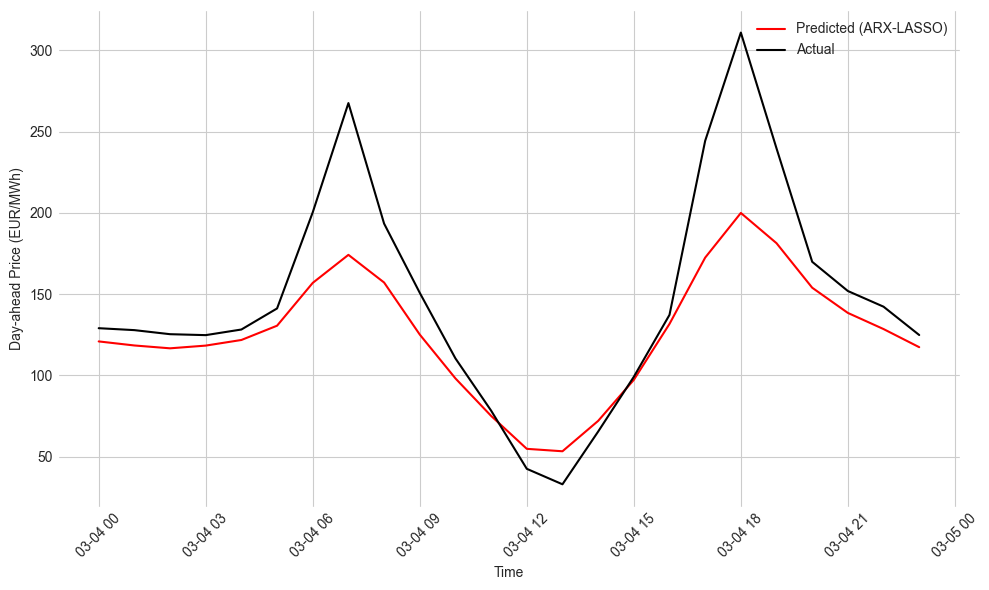

In [26]:
# Plotting true and forecasted for a specific day

day = "2026-03-04"

day_df = test_df.loc[day]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df.index, day_df['price_pred_arxlasso'],
         color='red', label='Predicted (ARX-LASSO)')

plt.plot(day_df.index, day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARX-LASSO with walk-forward CV

In [27]:
# Full training set up to June 30, 2025
train_df = df[df.index <= "2025-06-30 23:00:00"].copy()

train_df = train_df.dropna().copy()  # eliminate N/A from train (generated by lagging)

X_full = train_df[lag_cols + exog_features + seasonal]
y_full = train_df['price']

# CV period: Jan 1 → June 30, 2025
cv_start = pd.Timestamp("2025-01-01")
cv_end = pd.Timestamp("2025-06-30 23:00:00")

# Get CV indices (rows inside CV period)
cv_mask = (X_full.index >= cv_start) & (X_full.index <= cv_end)
X_cv = X_full[cv_mask]
y_cv = y_full[cv_mask]

# Hyperparameter grid
alphas = np.logspace(-1, 1.3, 20)

# Validation horizon
validation_days = 30
val_size = validation_days * 24  # hourly data

# TimeSeriesSplit for walk-forward CV
n_splits = (len(X_cv) - val_size) // val_size
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=val_size)

# ARX-LASSO pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

# Store CV results
results = []

for alpha in alphas:
    model.set_params(lasso__alpha=alpha)
    fold_scores = []

    for train_idx, val_idx in tscv.split(X_cv):
        # Train uses **all historical data before Jan 1, 2025 + CV training portion**
        X_train = pd.concat([X_full[X_full.index < cv_start], X_cv.iloc[train_idx]])
        y_train = pd.concat([y_full[y_full.index < cv_start], y_cv.iloc[train_idx]])

        X_val = X_cv.iloc[val_idx]
        y_val = y_cv.iloc[val_idx]

        model.fit(X_train, y_train, lasso__sample_weight=weights.loc[X_train.index])
        y_pred = model.predict(X_val)
        fold_scores.append(dae(y_val, y_pred))

    results.append({
        "alpha": alpha,
        "dae": np.mean(fold_scores)
    })

results = pd.DataFrame(results)
best_alpha = results.loc[results["dae"].idxmin(), "alpha"]

print(f"Best alpha: {best_alpha:.4f}")
print(f"Best CV DAE: {results['dae'].min():.4f}")

Best alpha: 0.1000
Best CV DAE: 14.5456


In [28]:
# --- Refit best model on full training data ---
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=best_alpha, max_iter=10000))
])

final_model.fit(X_full, y_full, lasso__sample_weight=weights.loc[X_full.index])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, max_iter=10000))])

In [29]:
# show features with non-zero coefficients
lasso = final_model.named_steps["lasso"]
coef_series = pd.Series(lasso.coef_, index=lag_cols + exog_features + seasonal)
selected_features = coef_series[coef_series != 0].sort_values(ascending=False)
print(selected_features)

price_24h                41.303522
gas_price_lag_48h        21.144707
load                     15.333990
price_168h               12.028335
co2_price_lag_48h         6.162054
price_72h                 5.013439
price_volatility_24h      4.646341
dow_cos                   2.850305
total_generation_168h     2.849541
net_export_48h            2.543894
temperature               2.313783
hour_sin                  1.831850
price_25h                 1.283464
price_37h                 0.922371
total_generation_72h      0.913825
price_61h                 0.855130
price_60h                 0.320496
dow_sin                   0.230598
price_62h                 0.088863
price_30h                -0.019321
month_sin                -0.102253
price_54h                -0.216802
price_69h                -0.287004
price_53h                -0.748513
is_holiday               -0.768259
load_ramp                -0.943469
net_export_72h           -0.961920
price_68h                -0.977951
wind_speed          

In [30]:
# features dropped by lasso
discarded_features = coef_series[coef_series == 0].sort_values(ascending=False)
print(discarded_features)

price_48h             0.0
price_26h             0.0
price_50h            -0.0
price_51h            -0.0
price_52h            -0.0
price_55h            -0.0
price_56h            -0.0
price_57h            -0.0
price_58h             0.0
price_59h             0.0
price_63h             0.0
price_64h             0.0
price_65h             0.0
price_66h            -0.0
price_67h            -0.0
price_70h            -0.0
price_71h             0.0
net_export_168h       0.0
coal_price_lag_48h    0.0
price_49h             0.0
price_47h            -0.0
price_46h            -0.0
price_35h             0.0
price_27h            -0.0
price_28h            -0.0
price_29h            -0.0
price_31h            -0.0
price_32h            -0.0
price_33h             0.0
price_34h             0.0
price_36h             0.0
price_45h            -0.0
price_38h             0.0
price_39h             0.0
price_40h             0.0
price_41h             0.0
price_42h            -0.0
price_43h            -0.0
price_44h   

In [31]:
# Predict on test set
test_df = test_df.sort_index().copy()
X_test = test_df[lag_cols + exog_features + seasonal]
y_pred_test = final_model.predict(X_test)

# Add predictions to test_df
test_df["price_pred_bestlasso"] = y_pred_test

In [32]:
# performance of the best ARX-LASSO prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_bestlasso"])
smape_score = smape(test_df["price"], test_df["price_pred_bestlasso"])
dae_score = dae(test_df["price"], test_df["price_pred_bestlasso"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 15.0446
DAE: 15.0446
SMAPE: 28.2637


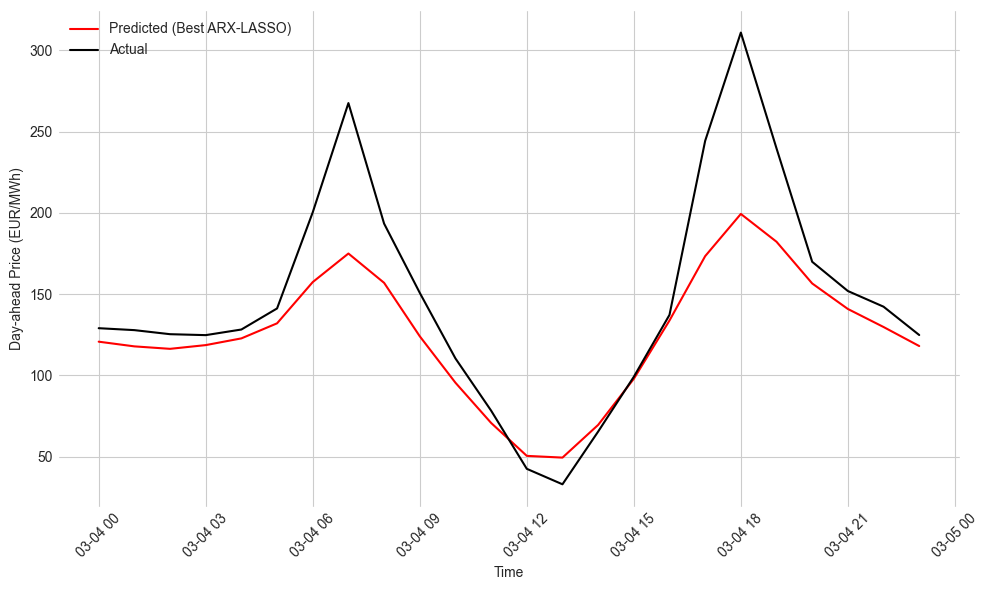

In [33]:
# Plotting true and forecasted for a specific day

day = "2026-03-04"

day_df = test_df.loc[day]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df.index, day_df['price_pred_bestlasso'],
         color='red', label='Predicted (Best ARX-LASSO)')

plt.plot(day_df.index, day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## XGBoost